# Hardware Accelerators for Robotics and AI 
# Lab Assignment 3: Numba Acceleration

**Students** Cibiraj Esakkiraja , Tahseen Fayyaz , Aarne Ollila

This notebook is prepared as a full lab-report notebook. Run all cells on the UTU GPU server or another computer with an NVIDIA GPU and CUDA support.

The notebook contains:
- Task 1: CPU acceleration with Numba
- Task 2: CPU/GPU acceleration with `@vectorize`
- Task 3: Custom CUDA kernels
- Task 4: Multidimensional CUDA kernels
- Task 5: Basic image processing

In [1]:
import math
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt

import numba as nb
from numba import cuda, vectorize, float32, float64, int64

warnings.filterwarnings("ignore")

print("Numba version:", nb.__version__)
print("CUDA available:", cuda.is_available())

if cuda.is_available():
    print("CUDA device:", cuda.get_current_device().name)
else:
    print("CUDA is not available. GPU parts will be skipped.")

Numba version: 0.65.1
CUDA available: True
CUDA device: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [2]:
def time_function(func, *args, repeat=5, warmup=1, sync_cuda=False):
    for _ in range(warmup):
        func(*args)
        if sync_cuda and cuda.is_available():
            cuda.synchronize()

    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        func(*args)
        if sync_cuda and cuda.is_available():
            cuda.synchronize()
        end = time.perf_counter()
        times.append(end - start)
    return min(times)


def plot_loglog(x, results_dict, title, xlabel="Input size", ylabel="Time (seconds)"):
    plt.figure(figsize=(8, 5))
    for label, y in results_dict.items():
        plt.plot(x, y, marker="o", label=label)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which="both")
    plt.legend()
    plt.show()

# Task 1 – Acceleration in CPU with Numba

We estimate π using the Monte Carlo method and compare normal Python, Numba JIT CPU, and Numba parallel CPU.

In [3]:
def monte_carlo_pi_python(nsamples):
    acc = 0
    for i in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if (x**2 + y**2) < 1.0:
            acc += 1
    return 4.0 * acc / nsamples


@nb.njit
def monte_carlo_pi_jit(nsamples):
    acc = 0
    for i in range(nsamples):
        x = np.random.random()
        y = np.random.random()
        if (x**2 + y**2) < 1.0:
            acc += 1
    return 4.0 * acc / nsamples


@nb.njit(parallel=True)
def monte_carlo_pi_jit_parallel(nsamples):
    acc = 0
    for i in nb.prange(nsamples):
        x = np.random.random()
        y = np.random.random()
        if (x**2 + y**2) < 1.0:
            acc += 1
    return 4.0 * acc / nsamples

In [4]:
nsamples_test = 1000

print("Python:", monte_carlo_pi_python(nsamples_test))
print("Numba JIT first call:", monte_carlo_pi_jit(nsamples_test))
print("Numba JIT second call:", monte_carlo_pi_jit(nsamples_test))
print("Numba parallel first call:", monte_carlo_pi_jit_parallel(nsamples_test))
print("Numba parallel second call:", monte_carlo_pi_jit_parallel(nsamples_test))

Python: 3.172
Numba JIT first call: 3.18
Numba JIT second call: 3.136
Numba parallel first call: 3.108
Numba parallel second call: 3.132


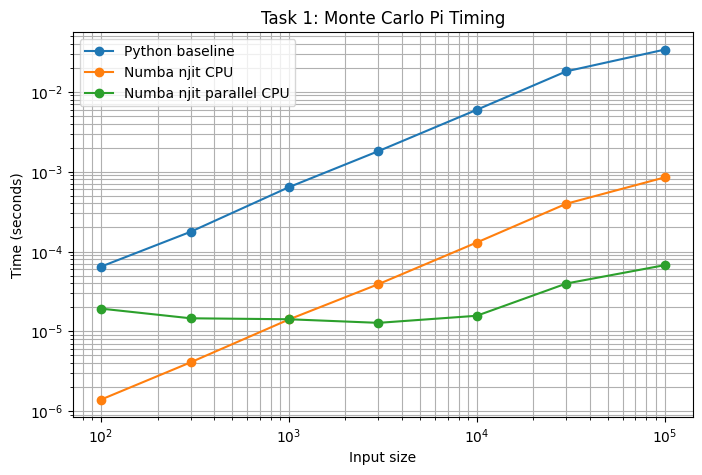

In [5]:
sample_sizes = np.array([100, 300, 1000, 3000, 10000, 30000, 100000])

python_times = []
jit_times = []
parallel_times = []

monte_carlo_pi_jit(10)
monte_carlo_pi_jit_parallel(10)

for n in sample_sizes:
    python_times.append(time_function(monte_carlo_pi_python, int(n), repeat=3, warmup=0))
    jit_times.append(time_function(monte_carlo_pi_jit, int(n), repeat=5, warmup=1))
    parallel_times.append(time_function(monte_carlo_pi_jit_parallel, int(n), repeat=5, warmup=1))

plot_loglog(
    sample_sizes,
    {
        "Python baseline": python_times,
        "Numba njit CPU": jit_times,
        "Numba njit parallel CPU": parallel_times,
    },
    "Task 1: Monte Carlo Pi Timing"
)

## Task 1 Answers

### (i) Why does the initial run with Numba take longer than Python baseline execution?

To execute the Numba function for the first time, it must first convert the Python bytecode into optimized machine code. This conversion is not instantaneous but rather takes some time. Therefore, the first-time function execution takes longer than the subsequent executions which leverage the optimized machine code.

### (ii) Line chart

The figure above illustrates the execution time against an increasing value of `nsamples` from 100 to 100000 in a log-log line chart.

### (iii) What is `nopython`?

The value `nopython=True` indicates that Numba compiles the function into pure machine code with no fallback to object mode when compilation fails.

# Task 2 – Accelerating in CPU and GPU with `@vectorize`

The following two operations are implemented:
1.  Simple multiplication
2. Log-square root operation

We compare NumPy, Numba vectorize CPU, Numba vectorize parallel CPU, and CUDA GPU when available.

In [6]:
def numpy_multiply_f32(a, b):
    return a * b

@vectorize([float32(float32, float32)], target="cpu")
def numba_multiply_cpu_f32(a, b):
    return a * b

@vectorize([float32(float32, float32)], target="parallel")
def numba_multiply_parallel_f32(a, b):
    return a * b

if cuda.is_available():
    @vectorize([float32(float32, float32)], target="cuda")
    def numba_multiply_cuda_f32(a, b):
        return a * b


def numpy_logexpr_f32(a, b):
    return np.log(a + 1.0) + np.sqrt(b)

@vectorize([float32(float32, float32)], target="cpu")
def numba_logexpr_cpu_f32(a, b):
    return math.log(a + 1.0) + math.sqrt(b)

@vectorize([float32(float32, float32)], target="parallel")
def numba_logexpr_parallel_f32(a, b):
    return math.log(a + 1.0) + math.sqrt(b)

if cuda.is_available():
    @vectorize([float32(float32, float32)], target="cuda")
    def numba_logexpr_cuda_f32(a, b):
        return math.log(a + 1.0) + math.sqrt(b)

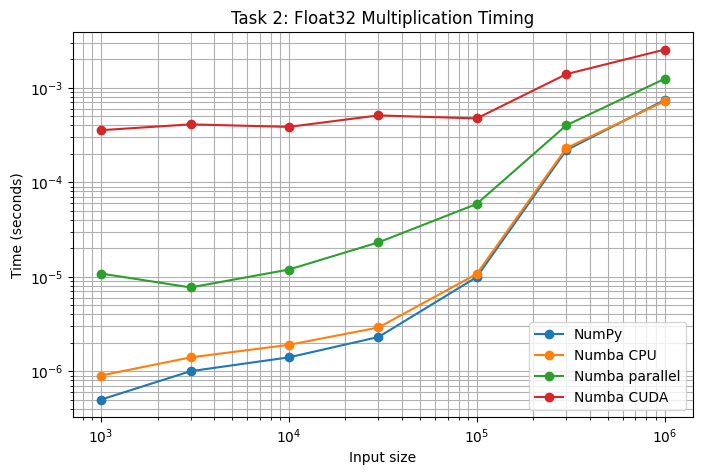

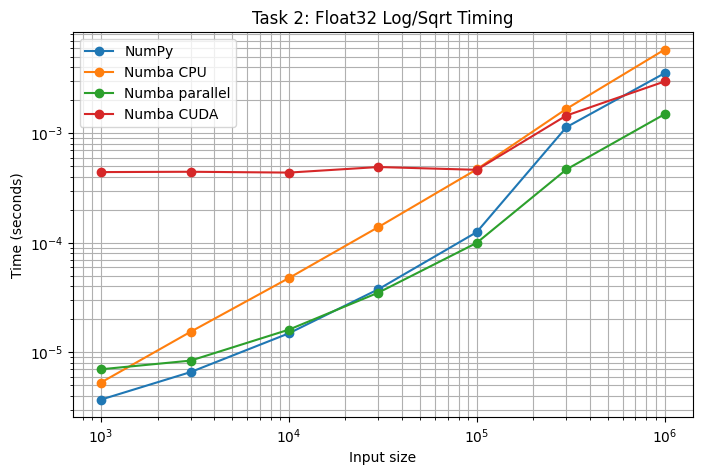

In [7]:
sizes = np.array([1000, 3000, 10000, 30000, 100000, 300000, 1000000])

mul_results = {"NumPy": [], "Numba CPU": [], "Numba parallel": []}
log_results = {"NumPy": [], "Numba CPU": [], "Numba parallel": []}

if cuda.is_available():
    mul_results["Numba CUDA"] = []
    log_results["Numba CUDA"] = []

a = np.random.uniform(0.5, 2.0, size=1000).astype(np.float32)
b = np.random.uniform(0.5, 2.0, size=1000).astype(np.float32)
numba_multiply_cpu_f32(a, b)
numba_multiply_parallel_f32(a, b)
numba_logexpr_cpu_f32(a, b)
numba_logexpr_parallel_f32(a, b)

if cuda.is_available():
    numba_multiply_cuda_f32(a, b)
    numba_logexpr_cuda_f32(a, b)
    cuda.synchronize()

for n in sizes:
    a = np.random.uniform(0.5, 2.0, size=n).astype(np.float32)
    b = np.random.uniform(0.5, 2.0, size=n).astype(np.float32)

    mul_results["NumPy"].append(time_function(numpy_multiply_f32, a, b))
    mul_results["Numba CPU"].append(time_function(numba_multiply_cpu_f32, a, b))
    mul_results["Numba parallel"].append(time_function(numba_multiply_parallel_f32, a, b))

    log_results["NumPy"].append(time_function(numpy_logexpr_f32, a, b))
    log_results["Numba CPU"].append(time_function(numba_logexpr_cpu_f32, a, b))
    log_results["Numba parallel"].append(time_function(numba_logexpr_parallel_f32, a, b))

    if cuda.is_available():
        mul_results["Numba CUDA"].append(time_function(numba_multiply_cuda_f32, a, b, sync_cuda=True))
        log_results["Numba CUDA"].append(time_function(numba_logexpr_cuda_f32, a, b, sync_cuda=True))

plot_loglog(sizes, mul_results, "Task 2: Float32 Multiplication Timing")
plot_loglog(sizes, log_results, "Task 2: Float32 Log/Sqrt Timing")

## Task 2 – 64-bit Precision

Now we repeat using float64 and int64.

In [8]:
def numpy_multiply_f64(a, b):
    return a * b

@vectorize([float64(float64, float64)], target="cpu")
def numba_multiply_cpu_f64(a, b):
    return a * b

@vectorize([float64(float64, float64)], target="parallel")
def numba_multiply_parallel_f64(a, b):
    return a * b

if cuda.is_available():
    @vectorize([float64(float64, float64)], target="cuda")
    def numba_multiply_cuda_f64(a, b):
        return a * b


def numpy_int64_expr(a, b):
    return a * b + a

@vectorize([int64(int64, int64)], target="cpu")
def numba_int64_cpu(a, b):
    return a * b + a

@vectorize([int64(int64, int64)], target="parallel")
def numba_int64_parallel(a, b):
    return a * b + a

if cuda.is_available():
    @vectorize([int64(int64, int64)], target="cuda")
    def numba_int64_cuda(a, b):
        return a * b + a

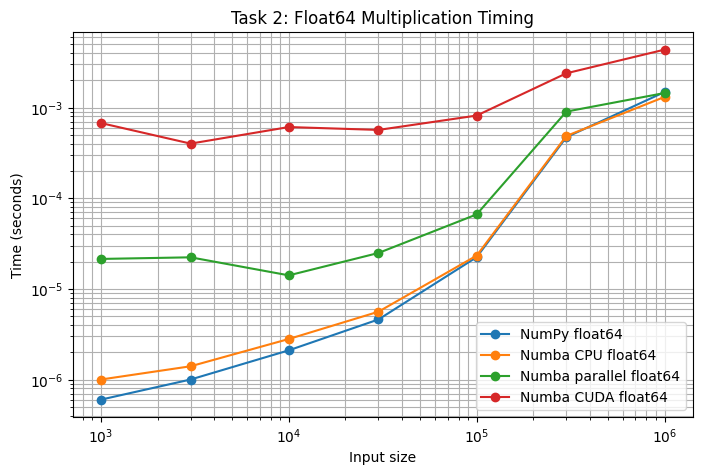

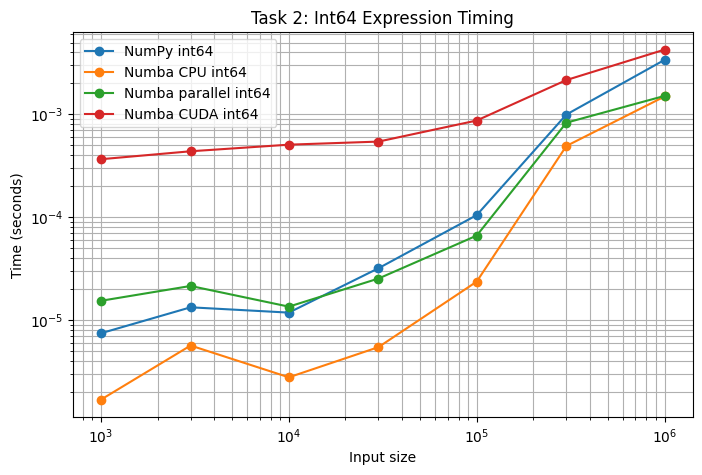

In [9]:
f64_results = {"NumPy float64": [], "Numba CPU float64": [], "Numba parallel float64": []}
i64_results = {"NumPy int64": [], "Numba CPU int64": [], "Numba parallel int64": []}

if cuda.is_available():
    f64_results["Numba CUDA float64"] = []
    i64_results["Numba CUDA int64"] = []

for n in sizes:
    a64 = np.random.uniform(0.5, 2.0, size=n).astype(np.float64)
    b64 = np.random.uniform(0.5, 2.0, size=n).astype(np.float64)
    ia = np.random.randint(1, 100, size=n).astype(np.int64)
    ib = np.random.randint(1, 100, size=n).astype(np.int64)

    f64_results["NumPy float64"].append(time_function(numpy_multiply_f64, a64, b64))
    f64_results["Numba CPU float64"].append(time_function(numba_multiply_cpu_f64, a64, b64))
    f64_results["Numba parallel float64"].append(time_function(numba_multiply_parallel_f64, a64, b64))

    i64_results["NumPy int64"].append(time_function(numpy_int64_expr, ia, ib))
    i64_results["Numba CPU int64"].append(time_function(numba_int64_cpu, ia, ib))
    i64_results["Numba parallel int64"].append(time_function(numba_int64_parallel, ia, ib))

    if cuda.is_available():
        f64_results["Numba CUDA float64"].append(time_function(numba_multiply_cuda_f64, a64, b64, sync_cuda=True))
        i64_results["Numba CUDA int64"].append(time_function(numba_int64_cuda, ia, ib, sync_cuda=True))

plot_loglog(sizes, f64_results, "Task 2: Float64 Multiplication Timing")
plot_loglog(sizes, i64_results, "Task 2: Int64 Expression Timing")

In [10]:
def polar_distance_numpy(rho1, theta1, rho2, theta2):
    x1 = rho1 * np.cos(theta1)
    y1 = rho1 * np.sin(theta1)
    x2 = rho2 * np.cos(theta2)
    y2 = rho2 * np.sin(theta2)
    return np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

@vectorize([float32(float32, float32, float32, float32)], target="parallel")
def polar_distance_parallel(rho1, theta1, rho2, theta2):
    x1 = rho1 * math.cos(theta1)
    y1 = rho1 * math.sin(theta1)
    x2 = rho2 * math.cos(theta2)
    y2 = rho2 * math.sin(theta2)
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

if cuda.is_available():
    @cuda.jit(device=True)
    def polar_to_cartesian(rho, theta):
        x = rho * math.cos(theta)
        y = rho * math.sin(theta)
        return x, y

    @vectorize([float32(float32, float32, float32, float32)], target="cuda")
    def polar_distance_cuda(rho1, theta1, rho2, theta2):
        x1, y1 = polar_to_cartesian(rho1, theta1)
        x2, y2 = polar_to_cartesian(rho2, theta2)
        return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

In [11]:
n = 1000000
rho1 = np.random.uniform(0.5, 1.5, size=n).astype(np.float32)
theta1 = np.random.uniform(-np.pi, np.pi, size=n).astype(np.float32)
rho2 = np.random.uniform(0.5, 1.5, size=n).astype(np.float32)
theta2 = np.random.uniform(-np.pi, np.pi, size=n).astype(np.float32)

print("NumPy time:", time_function(polar_distance_numpy, rho1, theta1, rho2, theta2, repeat=3))
print("Parallel CPU time:", time_function(polar_distance_parallel, rho1, theta1, rho2, theta2, repeat=3))

if cuda.is_available():
    print("CUDA time:", time_function(polar_distance_cuda, rho1, theta1, rho2, theta2, repeat=3, sync_cuda=True))

NumPy time: 0.008414500000071712
Parallel CPU time: 0.0030714999993506353
CUDA time: 0.003137100000458304


## Comments on Task 2

For small arrays, GPU acceleration will take longer since kernel execution time and memory transfer time will have a lot of overheads. For larger arrays, the use of GPU acceleration is important, as a lot of elements are handled concurrently.

64 bit processing requires higher bandwidth compared to 32 bit processing. Performance for float64 processing is lower as well compared to float32 processing.

# Task 3 – Custom CUDA Kernels

We implement a square-root operation and compare NumPy, Numba CPU, vectorized implementations, and a custom CUDA kernel.

In [12]:
# Task 3 – Custom CUDA Kernels

# Baseline NumPy version
def sqrt_numpy(x):
    return np.sqrt(x)

# Pure Python baseline version
def sqrt_python_baseline(x):
    out = np.empty_like(x)
    for i in range(len(x)):
        out[i] = math.sqrt(x[i])
    return out

# Numba CPU accelerated version
@nb.njit
def sqrt_numba_cpu(x):
    out = np.empty_like(x)
    for i in range(x.size):
        out[i] = math.sqrt(x[i])
    return out

# Numba vectorized parallel CPU version
@vectorize([float32(float32)], target="parallel")
def sqrt_vectorize_parallel(x):
    return math.sqrt(x)

# Numba vectorized CUDA GPU version and custom CUDA kernel
if cuda.is_available():
    @vectorize([float32(float32)], target="cuda")
    def sqrt_vectorize_cuda(x):
        return math.sqrt(x)

    @cuda.jit
    def sqrt_kernel(input_array, output_array):
        idx = cuda.grid(1)
        if idx < input_array.size:
            output_array[idx] = math.sqrt(input_array[idx])

In [13]:
def run_custom_sqrt_kernel(x, threads_per_block=256):
    out = np.empty_like(x)

    if not cuda.is_available():
        return out

    d_x = cuda.to_device(x)
    d_out = cuda.device_array_like(x)

    blocks_per_grid = math.ceil(x.size / threads_per_block)

    sqrt_kernel[blocks_per_grid, threads_per_block](d_x, d_out)
    cuda.synchronize()

    return d_out.copy_to_host()

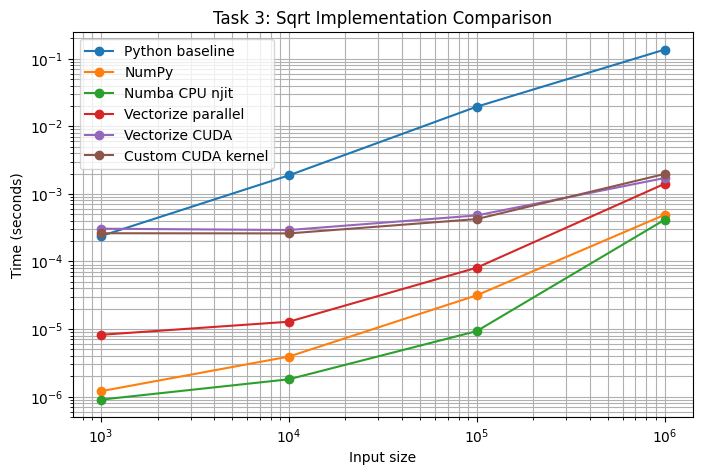

In [14]:
sqrt_sizes = np.array([1000, 10000, 100000, 1000000])

sqrt_results = {
    "Python baseline": [],
    "NumPy": [],
    "Numba CPU njit": [],
    "Vectorize parallel": []
}

if cuda.is_available():
    sqrt_results["Vectorize CUDA"] = []
    sqrt_results["Custom CUDA kernel"] = []

# Warm-up compilation
x = np.random.uniform(0.1, 100.0, size=1000).astype(np.float32)
sqrt_numba_cpu(x)
sqrt_vectorize_parallel(x)

if cuda.is_available():
    sqrt_vectorize_cuda(x)
    run_custom_sqrt_kernel(x)
    cuda.synchronize()

for n in sqrt_sizes:
    x = np.random.uniform(0.1, 100.0, size=n).astype(np.float32)

    sqrt_results["Python baseline"].append(
        time_function(sqrt_python_baseline, x, repeat=1, warmup=0)
    )

    sqrt_results["NumPy"].append(
        time_function(sqrt_numpy, x, repeat=5, warmup=1)
    )

    sqrt_results["Numba CPU njit"].append(
        time_function(sqrt_numba_cpu, x, repeat=5, warmup=1)
    )

    sqrt_results["Vectorize parallel"].append(
        time_function(sqrt_vectorize_parallel, x, repeat=5, warmup=1)
    )

    if cuda.is_available():
        sqrt_results["Vectorize CUDA"].append(
            time_function(sqrt_vectorize_cuda, x, repeat=5, warmup=1, sync_cuda=True)
        )

        sqrt_results["Custom CUDA kernel"].append(
            time_function(run_custom_sqrt_kernel, x, repeat=5, warmup=1, sync_cuda=True)
        )

plot_loglog(sqrt_sizes, sqrt_results, "Task 3: Sqrt Implementation Comparison")

Blocks per grid: 15625, Threads per block: 64, Total threads: 1000000, Time: 0.001485 s
Blocks per grid: 7813, Threads per block: 128, Total threads: 1000064, Time: 0.001645 s
Blocks per grid: 3907, Threads per block: 256, Total threads: 1000192, Time: 0.001311 s
Blocks per grid: 1954, Threads per block: 512, Total threads: 1000448, Time: 0.001538 s


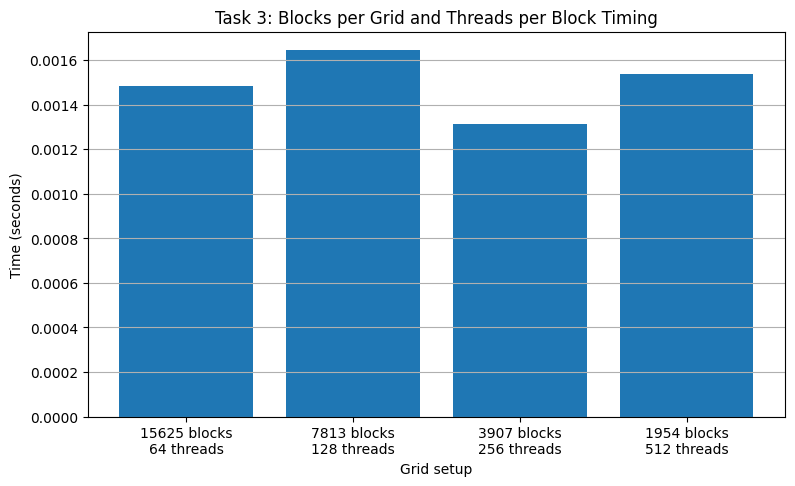

In [15]:
# Task 3.3 – Different grid setups

if cuda.is_available():
    n = 1000000
    x = np.random.uniform(0.1, 100.0, size=n).astype(np.float32)

    grid_setups = [
        (15625, 64),
        (7813, 128),
        (3907, 256),
        (1954, 512),
    ]

    setup_labels = []
    setup_times = []

    for blocks, threads in grid_setups:

        def run_fixed_grid():
            d_x = cuda.to_device(x)
            d_out = cuda.device_array_like(x)

            sqrt_kernel[blocks, threads](d_x, d_out)
            cuda.synchronize()

            return d_out.copy_to_host()

        t = time_function(run_fixed_grid, repeat=5, warmup=1, sync_cuda=True)

        setup_labels.append(f"{blocks} blocks\n{threads} threads")
        setup_times.append(t)

        print(
            f"Blocks per grid: {blocks}, "
            f"Threads per block: {threads}, "
            f"Total threads: {blocks * threads}, "
            f"Time: {t:.6f} s"
        )

    plt.figure(figsize=(9, 5))
    plt.bar(setup_labels, setup_times)
    plt.xlabel("Grid setup")
    plt.ylabel("Time (seconds)")
    plt.title("Task 3: Blocks per Grid and Threads per Block Timing")
    plt.grid(True, axis="y")
    plt.show()

else:
    print("CUDA unavailable, grid setup test skipped.")

In [16]:
# Task 3.5 – Measuring copy time and kernel execution time

if cuda.is_available():
    n = 1000000
    x = np.random.uniform(0.1, 100.0, size=n).astype(np.float32)

    threads_per_block = 256
    blocks_per_grid = math.ceil(n / threads_per_block)

    start = time.perf_counter()
    d_x = cuda.to_device(x)
    cuda.synchronize()
    h2d_time = time.perf_counter() - start

    d_out = cuda.device_array_like(x)

    start = time.perf_counter()
    sqrt_kernel[blocks_per_grid, threads_per_block](d_x, d_out)
    cuda.synchronize()
    kernel_time = time.perf_counter() - start

    start = time.perf_counter()
    out = d_out.copy_to_host()
    cuda.synchronize()
    d2h_time = time.perf_counter() - start

    total_time = h2d_time + kernel_time + d2h_time
    copy_time = h2d_time + d2h_time

    print("Host to device copy time:", h2d_time)
    print("Kernel execution time:", kernel_time)
    print("Device to host copy time:", d2h_time)
    print("Total measured time:", total_time)
    print("Copy percentage:", 100 * copy_time / total_time, "%")

else:
    print("CUDA unavailable, copy-time analysis skipped.")

Host to device copy time: 0.0009781000007933471
Kernel execution time: 0.0003983000005973736
Device to host copy time: 0.0005407999997260049
Total measured time: 0.0019172000011167256
Copy percentage: 79.22491130996386 %


In [17]:
# Task 3.6 – Grid-stride kernel where each thread processes multiple elements

if cuda.is_available():
    @cuda.jit
    def sqrt_kernel_grid_stride(input_array, output_array):
        idx = cuda.grid(1)
        stride = cuda.gridsize(1)

        for i in range(idx, input_array.size, stride):
            output_array[i] = math.sqrt(input_array[i])

In [18]:
def run_grid_stride_sqrt_kernel(x, threads_per_block=256, total_thread_fraction=0.5):
    out = np.empty_like(x)

    if not cuda.is_available():
        return out

    d_x = cuda.to_device(x)
    d_out = cuda.device_array_like(x)

    max_threads = max(1, int(x.size * total_thread_fraction))
    blocks_per_grid = max(1, math.ceil(max_threads / threads_per_block))

    sqrt_kernel_grid_stride[blocks_per_grid, threads_per_block](d_x, d_out)
    cuda.synchronize()

    return d_out.copy_to_host()

Grid-stride setup: blocks=7813, threads=64, total threads=500032, time=0.001345 s
Grid-stride setup: blocks=3907, threads=128, total threads=500096, time=0.001510 s
Grid-stride setup: blocks=1954, threads=256, total threads=500224, time=0.001401 s
Grid-stride setup: blocks=977, threads=512, total threads=500224, time=0.001380 s


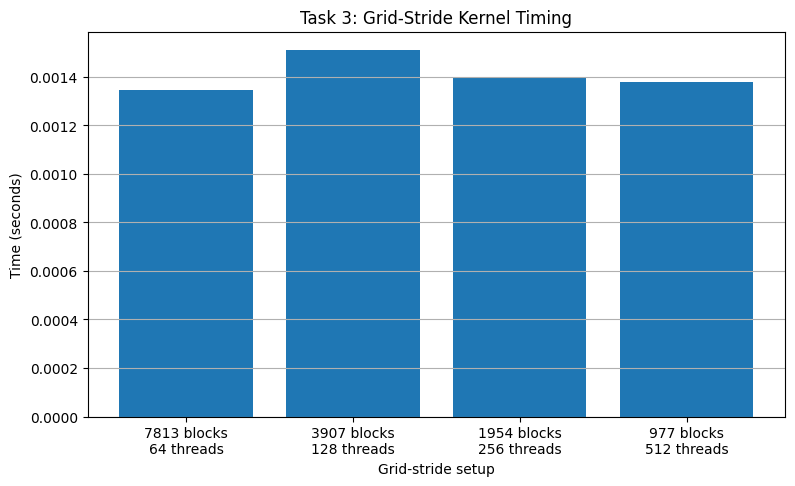

In [19]:
if cuda.is_available():
    n = 1000000
    x = np.random.uniform(0.1, 100.0, size=n).astype(np.float32)

    grid_stride_setups = [
        (7813, 64),
        (3907, 128),
        (1954, 256),
        (977, 512),
    ]

    stride_labels = []
    stride_times = []

    for blocks, threads in grid_stride_setups:

        def run_fixed_grid_stride():
            d_x = cuda.to_device(x)
            d_out = cuda.device_array_like(x)

            sqrt_kernel_grid_stride[blocks, threads](d_x, d_out)
            cuda.synchronize()

            return d_out.copy_to_host()

        t = time_function(run_fixed_grid_stride, repeat=5, warmup=1, sync_cuda=True)

        stride_labels.append(f"{blocks} blocks\n{threads} threads")
        stride_times.append(t)

        print(
            f"Grid-stride setup: blocks={blocks}, "
            f"threads={threads}, "
            f"total threads={blocks * threads}, "
            f"time={t:.6f} s"
        )

    plt.figure(figsize=(9, 5))
    plt.bar(stride_labels, stride_times)
    plt.xlabel("Grid-stride setup")
    plt.ylabel("Time (seconds)")
    plt.title("Task 3: Grid-Stride Kernel Timing")
    plt.grid(True, axis="y")
    plt.show()

else:
    print("CUDA unavailable, grid-stride test skipped.")

In [20]:
# Task 3.4 – Test what happens when input size grows considerably

if cuda.is_available():
    try:
        n_large = 2_000_000_000
        x_large = np.random.uniform(0.1, 100.0, size=n_large).astype(np.float32)

        out_large = run_custom_sqrt_kernel(x_large)

        print("Large input succeeded.")

    except Exception as e:
        print("Large input failed.")
        print("Error type:", type(e).__name__)
        print("Message:", str(e))
else:
    print("CUDA unavailable, large input test skipped.")

Large input succeeded.


## Task 3 Answers

As the size of input increases substantially, the GPU may not have enough memory since the arrays are too big to fit in the memory space of the GPU.

These issues can be addressed by breaking down the dataset into smaller batches, working with lower data types like `float32` instead of `float64`, reusing GPU memory space, and minimizing host-to-device transfers that are unnecessary.

The copy time analysis demonstrates that in simple operations like square root, much of the time taken in executing the operation is taken by the data transfer between the host memory and the GPU memory space.

# Task 4 – Multidimensional Kernels

We compute element-wise operations on a 2D matrix using a 2D CUDA grid without flattening the matrix.

In [21]:
def matrix_simple_numpy(A):
    return A * A + 2.0 * A + 1.0

def matrix_complex_numpy(A):
    return np.sin(A) + np.log(A + 1.0) + np.sqrt(A)

if cuda.is_available():
    @cuda.jit(device=True)
    def simple_device_op(x):
        return x * x + 2.0 * x + 1.0

    @cuda.jit(device=True)
    def complex_device_op(x):
        return math.sin(x) + math.log(x + 1.0) + math.sqrt(x)

    @cuda.jit
    def matrix_simple_kernel(A, B):
        row, col = cuda.grid(2)
        if row < A.shape[0] and col < A.shape[1]:
            B[row, col] = simple_device_op(A[row, col])

    @cuda.jit
    def matrix_complex_kernel(A, B):
        row, col = cuda.grid(2)
        if row < A.shape[0] and col < A.shape[1]:
            B[row, col] = complex_device_op(A[row, col])

In [22]:
def run_matrix_kernel(A, kernel, threads=(16, 16)):
    if not cuda.is_available():
        return np.empty_like(A)

    d_A = cuda.to_device(A)
    d_B = cuda.device_array_like(A)

    blocks = (
        math.ceil(A.shape[0] / threads[0]),
        math.ceil(A.shape[1] / threads[1])
    )

    kernel[blocks, threads](d_A, d_B)
    cuda.synchronize()

    return d_B.copy_to_host()

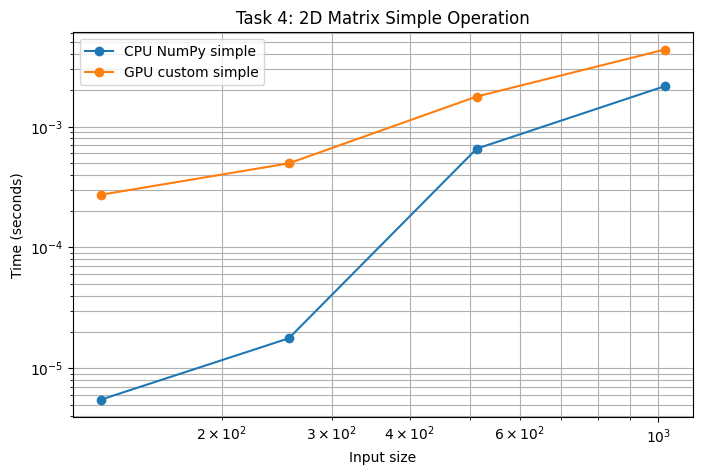

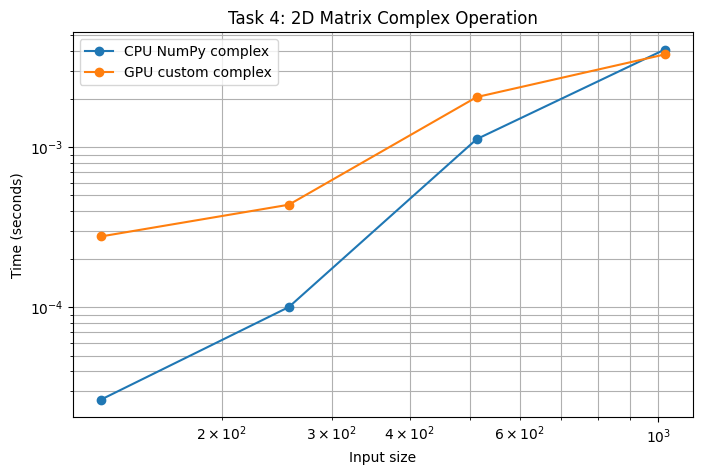

In [23]:
matrix_sizes = np.array([128, 256, 512, 1024])

simple_matrix_results = {"CPU NumPy simple": []}
complex_matrix_results = {"CPU NumPy complex": []}

if cuda.is_available():
    simple_matrix_results["GPU custom simple"] = []
    complex_matrix_results["GPU custom complex"] = []

for m in matrix_sizes:
    A = np.random.uniform(0.1, 10.0, size=(m, m)).astype(np.float32)

    simple_matrix_results["CPU NumPy simple"].append(time_function(matrix_simple_numpy, A, repeat=3))
    complex_matrix_results["CPU NumPy complex"].append(time_function(matrix_complex_numpy, A, repeat=3))

    if cuda.is_available():
        simple_matrix_results["GPU custom simple"].append(time_function(run_matrix_kernel, A, matrix_simple_kernel, repeat=3, sync_cuda=True))
        complex_matrix_results["GPU custom complex"].append(time_function(run_matrix_kernel, A, matrix_complex_kernel, repeat=3, sync_cuda=True))

plot_loglog(matrix_sizes, simple_matrix_results, "Task 4: 2D Matrix Simple Operation")
plot_loglog(matrix_sizes, complex_matrix_results, "Task 4: 2D Matrix Complex Operation")

## Comments for Task 4

    With respect to small matrix sizes, CPU NumPy is faster compared to GPU since launching tasks on the GPU is costly. However, for larger matrix sizes, GPU starts being useful since more elements can be handled in parallel.

    The complex operation can be performed more efficiently using GPU compared to the simple operation since there will be more arithmetic computations per element.

# Task 5 – Basic Image Processing

We implement a custom black-and-white filter using weighted RGB averaging.

Weights used:
- Red = 0.30
- Green = 0.59
- Blue = 0.11

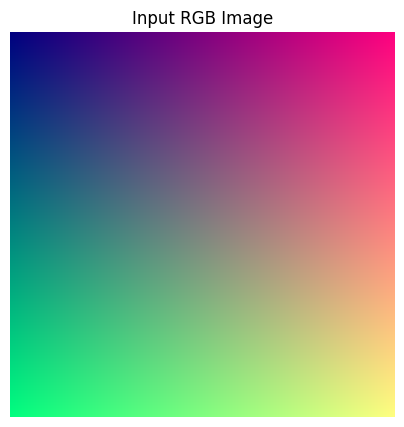

In [24]:
height, width = 512, 512

image = np.zeros((height, width, 3), dtype=np.float32)
image[:, :, 0] = np.linspace(0, 1, width)
image[:, :, 1] = np.linspace(0, 1, height)[:, None]
image[:, :, 2] = 0.5

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Input RGB Image")
plt.axis("off")
plt.show()

In [25]:
def bw_filter_numpy(img):
    return 0.30 * img[:, :, 0] + 0.59 * img[:, :, 1] + 0.11 * img[:, :, 2]

if cuda.is_available():
    @cuda.jit
    def bw_filter_kernel(img, out):
        row, col = cuda.grid(2)
        if row < img.shape[0] and col < img.shape[1]:
            r = img[row, col, 0]
            g = img[row, col, 1]
            b = img[row, col, 2]
            out[row, col] = 0.30 * r + 0.59 * g + 0.11 * b

def run_bw_filter_cuda(img):
    if not cuda.is_available():
        return np.empty((img.shape[0], img.shape[1]), dtype=np.float32)

    d_img = cuda.to_device(img)
    d_out = cuda.device_array((img.shape[0], img.shape[1]), dtype=np.float32)

    threads = (16, 16)
    blocks = (
        math.ceil(img.shape[0] / threads[0]),
        math.ceil(img.shape[1] / threads[1])
    )

    bw_filter_kernel[blocks, threads](d_img, d_out)
    cuda.synchronize()

    return d_out.copy_to_host()

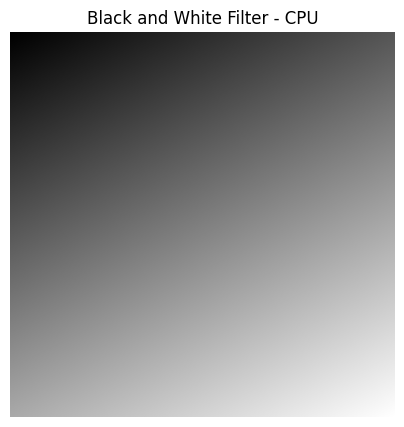

CPU BW filter time: 0.000830699998914497


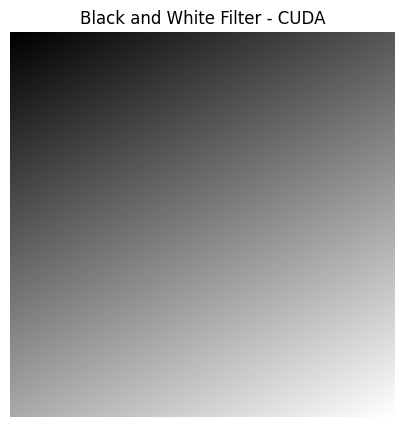

GPU BW filter time: 0.0024650000013934914


In [26]:
bw_cpu = bw_filter_numpy(image)

plt.figure(figsize=(5, 5))
plt.imshow(bw_cpu, cmap="gray")
plt.title("Black and White Filter - CPU")
plt.axis("off")
plt.show()

print("CPU BW filter time:", time_function(bw_filter_numpy, image, repeat=5))

if cuda.is_available():
    bw_gpu = run_bw_filter_cuda(image)

    plt.figure(figsize=(5, 5))
    plt.imshow(bw_gpu, cmap="gray")
    plt.title("Black and White Filter - CUDA")
    plt.axis("off")
    plt.show()

    print("GPU BW filter time:", time_function(run_bw_filter_cuda, image, repeat=5, sync_cuda=True))
else:
    print("CUDA unavailable, GPU BW filter skipped.")

## Optional Grade 5 – Gaussian Blur Filter

This implements a simple 3×3 Gaussian blur kernel.

In [27]:
if cuda.is_available():
    @cuda.jit
    def gaussian_blur_kernel(gray, out):
        row, col = cuda.grid(2)

        if row >= 1 and row < gray.shape[0] - 1 and col >= 1 and col < gray.shape[1] - 1:
            value = (
                1.0 * gray[row - 1, col - 1] + 2.0 * gray[row - 1, col] + 1.0 * gray[row - 1, col + 1] +
                2.0 * gray[row,     col - 1] + 4.0 * gray[row,     col] + 2.0 * gray[row,     col + 1] +
                1.0 * gray[row + 1, col - 1] + 2.0 * gray[row + 1, col] + 1.0 * gray[row + 1, col + 1]
            ) / 16.0

            out[row, col] = value

def gaussian_blur_numpy(gray):
    out = np.copy(gray)
    for i in range(1, gray.shape[0] - 1):
        for j in range(1, gray.shape[1] - 1):
            out[i, j] = (
                1.0 * gray[i - 1, j - 1] + 2.0 * gray[i - 1, j] + 1.0 * gray[i - 1, j + 1] +
                2.0 * gray[i,     j - 1] + 4.0 * gray[i,     j] + 2.0 * gray[i,     j + 1] +
                1.0 * gray[i + 1, j - 1] + 2.0 * gray[i + 1, j] + 1.0 * gray[i + 1, j + 1]
            ) / 16.0
    return out

def run_gaussian_blur_cuda(gray):
    if not cuda.is_available():
        return np.copy(gray)

    d_gray = cuda.to_device(gray)
    d_out = cuda.to_device(np.copy(gray))

    threads = (16, 16)
    blocks = (
        math.ceil(gray.shape[0] / threads[0]),
        math.ceil(gray.shape[1] / threads[1])
    )

    gaussian_blur_kernel[blocks, threads](d_gray, d_out)
    cuda.synchronize()

    return d_out.copy_to_host()

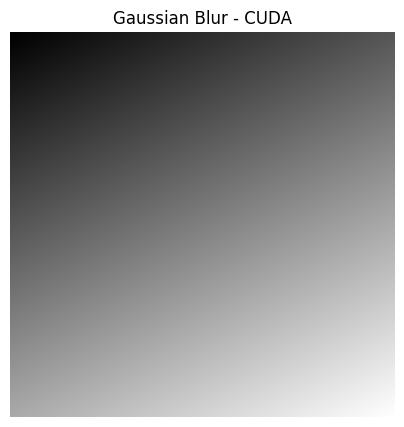

CUDA Gaussian blur time: 0.0017797000000427943


In [28]:
if cuda.is_available():
    gray = bw_filter_numpy(image).astype(np.float32)
    blurred = run_gaussian_blur_cuda(gray)

    plt.figure(figsize=(5, 5))
    plt.imshow(blurred, cmap="gray")
    plt.title("Gaussian Blur - CUDA")
    plt.axis("off")
    plt.show()

    print("CUDA Gaussian blur time:", time_function(run_gaussian_blur_cuda, gray, repeat=5, sync_cuda=True))
else:
    gray_small = bw_filter_numpy(image[:128, :128]).astype(np.float32)
    blurred_cpu = gaussian_blur_numpy(gray_small)

    plt.figure(figsize=(5, 5))
    plt.imshow(blurred_cpu, cmap="gray")
    plt.title("Gaussian Blur - CPU Small Image")
    plt.axis("off")
    plt.show()

    print("CUDA unavailable. CPU Gaussian blur shown on a small image.")

# Conclusion

From this lab, we have learned that:
1. `@njit` improves the runtime of Python code beyond the initial compilation.
2. The `parallel=True` option increases CPU efficiency for independent processes inside a loop.
3. `@vectorize` helps in optimizing independent processes within a CPU/GPU environment.
4. CUDA custom kernels offer better flexibility in defining grid/block structures.
5. Memory transfer between CPU and GPU may affect overall process time for basic computations.
6. CUDA 2D grids are effective for applications involving matrices/images.
7. GPUs can be effectively used where there are significant numbers of calculations required per input/output.